# Regression

### Imports and config

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

KORS_PATH    = Path('../data/original/Forts_IRAF_SAT_Kors.xlsx')
RAK_PATH     = Path('../data/original/Forts_IRAF_SAT_RAK.xlsx')
FEATURES_DIR = Path('../data/processed/features')
SELECTED_DIR = FEATURES_DIR / 'combined/per_video'
OUT_DIR      = Path('../data/processed/regression')
OUT_DIR.mkdir(parents=True, exist_ok=True)

PHASE_MAP = {
    'iraf_utgångsposition':  'selected_features_init.csv',
    'iraf_rörelsestart':     'selected_features_start.csv',
    'iraf_rörelseutförande': 'selected_features_execution.csv',
    'iraf_total':            'selected_features_total.csv',
}

## Load IRAF Scores

* Weighted mean over the aspect scores per phase
* Weighted mean over the phase means for the whole movement

In [55]:
def parse_iraf_per_video(xl, sheet_name):
    raw = xl.parse(sheet_name, header=None)
    col0 = raw.iloc[:, 0].astype(str)
    film_rows = raw.index[col0.str.contains('Film Nr', na=False)].tolist()
    film_rows.append(len(raw))
    records = []
    phase_weight_records = []
    for i, start in enumerate(film_rows[:-1]):
        video = col0.iloc[start].split(': ')[1].strip().zfill(4)
        block = raw.iloc[start:film_rows[i+1]]
        bc0 = block.iloc[:, 0].astype(str)
        up_idx = bc0[bc0.str.strip() == 'Utgångsposition'].index
        rs_idx = bc0[bc0.str.strip() == 'Rörelsestart'].index
        ru_idx = bc0[bc0.str.strip() == 'Rörelseutförande'].index
        if not (len(up_idx) and len(rs_idx) and len(ru_idx)):
            continue
        up_i, rs_i, ru_i = up_idx[0], rs_idx[0], ru_idx[0]
        end_i = film_rows[i+1]
        for phase, p_i in [('utgångsposition', up_i), ('rörelsestart', rs_i), ('rörelseutförande', ru_i)]:
            phase_weight_records.append({'video': video, 'phase': phase, 'phase_weight': raw.iloc[p_i, 1]})
        for phase, p_start, p_end in [
            ('utgångsposition', up_i+1, rs_i),
            ('rörelsestart',    rs_i+1, ru_i),
            ('rörelseutförande', ru_i+1, end_i)
        ]:
            for _, r in raw.iloc[p_start:p_end].iterrows():
                if pd.notna(r[1]) and pd.notna(r[3]) and r[5] != 'x':
                    records.append({'video': video, 'phase': phase,
                                    'weight': r[1], 'avvikelse': r[3]})
    return pd.DataFrame(records), pd.DataFrame(phase_weight_records)

kors_xl = pd.ExcelFile(KORS_PATH)
rak_xl  = pd.ExcelFile(RAK_PATH)
kors_df, kors_pw = parse_iraf_per_video(kors_xl, 'Sittande till stående')
rak_df,  rak_pw  = parse_iraf_per_video(rak_xl,  'Sittande till stående')
iraf_raw = pd.concat([kors_df, rak_df], ignore_index=True)
iraf_raw = iraf_raw.assign(w=iraf_raw['avvikelse'] * iraf_raw['weight'])

phase_weights = pd.concat([kors_pw, rak_pw]).groupby('phase')['phase_weight'].mean().to_dict()

iraf_pv = iraf_raw.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv.columns.name = None
iraf_pv.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv.columns[1:]]

total_w = sum(phase_weights.values())
iraf_pv['iraf_total'] = sum(iraf_pv[f'iraf_{p}'] * w for p, w in phase_weights.items()) / total_w

iraf_pv

,video,iraf_rörelsestart,iraf_rörelseutförande,iraf_utgångsposition,iraf_total
0,0028,2.0,0.6875,1.047619,1.314732
1,0030,0.0,0.0000,0.052632,0.019737
2,0045,2.0,0.9375,1.142857,1.412946
3,0047,0.0,0.3125,0.619048,0.310268
4,0059,2.0,0.9375,1.238095,1.448661
5,0061,0.0,0.1250,0.263158,0.129934
6,0074,2.0,0.9375,1.285714,1.466518
7,0076,0.0,0.5625,0.095238,0.176339
8,0091,1.0,0.6875,1.571429,1.136161
9,0093,1.0,0.3125,0.421053,0.611020


## Load top correlated features per phase

In [56]:
pose_all = (
    pd.read_csv(FEATURES_DIR / 'utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'rörelseutförande.csv'), on='video')
)
molab_all = (
    pd.read_csv(FEATURES_DIR / 'molab_utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_rörelseutförande.csv'), on='video')
)

pose_all['video']  = pose_all['video'].astype(str).str.zfill(3)
molab_all['video'] = molab_all['video'].astype(str).str.zfill(3)
pose_all  = pose_all.rename(columns={c: f'pose_{c}'  for c in pose_all.columns  if c != 'video'})
molab_all = molab_all.rename(columns={c: f'molab_{c}' for c in molab_all.columns if c != 'video'})

iraf = iraf_pv.copy()
iraf['video'] = iraf['video'].astype(str).str[-3:]

phase_dfs = {}
for target, fname in PHASE_MAP.items():
    sel = pd.read_csv(SELECTED_DIR / fname)
    pose_feats  = [f'pose_{f}'  for f in sel[sel['source'] == 'Pose']['feature'].tolist()]
    molab_feats = [f'molab_{f}' for f in sel[sel['source'] == 'MoLab']['feature'].tolist()]
    short = target.replace('iraf_', '')
    pose_df  = pose_all[['video'] + pose_feats]
    molab_df = molab_all[['video'] + molab_feats]
    phase_dfs[short] = {
        'pose':     pose_df,
        'molab':    molab_df,
        'combined': pose_df.merge(molab_df, on='video'),
        'y':        iraf[['video', target]],
    }

for phase, sources in phase_dfs.items():
    print(f"\n{phase}:")
    for source, val in sources.items():
        if source == 'y':
            scores = val.iloc[:, 1].round(2).tolist()
            print(f"  y: {scores}")
        else:
            print(f"  {source}: {val.shape} {val.columns[1:].tolist()}")


utgångsposition:
  pose: (10, 6) ['pose_initial_trunk_angle', 'pose_mean_trunk_angle', 'pose_forb_delta_trunk_flexion', 'pose_delta_trunk_flexion', 'pose_forb_rms_trunk_acceleration']
  molab: (10, 6) ['molab_delta_pelvis_tilt', 'molab_peak_pelvis_gyro', 'molab_forb_peak_pelvis_gyro', 'molab_mean_L_hip_flexion', 'molab_rms_pelvis_acc']
  combined: (10, 11) ['pose_initial_trunk_angle', 'pose_mean_trunk_angle', 'pose_forb_delta_trunk_flexion', 'pose_delta_trunk_flexion', 'pose_forb_rms_trunk_acceleration', 'molab_delta_pelvis_tilt', 'molab_peak_pelvis_gyro', 'molab_forb_peak_pelvis_gyro', 'molab_mean_L_hip_flexion', 'molab_rms_pelvis_acc']
  y: [1.05, 0.05, 1.14, 0.62, 1.24, 0.26, 1.29, 0.1, 1.57, 0.42]

rörelsestart:
  pose: (10, 6) ['pose_mean_head_trunk_angle', 'pose_trunk_hip_correlation', 'pose_initial_trunk_angle', 'pose_mean_trunk_angle', 'pose_forb_delta_trunk_flexion']
  molab: (10, 6) ['molab_peak_pelvis_gyro', 'molab_forb_peak_pelvis_gyro', 'molab_max_pelvis_tilt', 'molab_del

## Regression: LOOCV

In [57]:
MODELS = {
    'Linear':       LinearRegression(),
    'Ridge':        Ridge(),
    'RandomForest': RandomForestRegressor(max_depth=3, n_estimators=50, random_state=42),
}

FEATURE_SETS = ['pose', 'molab', 'combined']
MODEL_ORDER  = ['Linear', 'Ridge', 'RandomForest']

loo = LeaveOneOut()
loocv_results = []

for phase, data in phase_dfs.items():
    y = data['y'].iloc[:, 1].values
    for fs in FEATURE_SETS:
        X = data[fs].drop(columns='video').values
        feature_names = data[fs].drop(columns='video').columns.tolist()
        for model_name, model in MODELS.items():
            preds = np.empty(len(y))
            importances = []
            for train_idx, test_idx in loo.split(X):
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X[train_idx])
                X_test  = scaler.transform(X[test_idx])
                m = clone(model)
                m.fit(X_train, y[train_idx])
                preds[test_idx] = m.predict(X_test)
                if model_name == 'RandomForest':
                    importances.append(m.feature_importances_)
            entry = {
                'phase':       phase,
                'feature_set': fs,
                'model':       model_name,
                'y_true':      y.copy(),
                'y_pred':      preds,
            }
            if model_name == 'RandomForest':
                entry['feature_names']        = feature_names
                entry['mean_importances'] = np.mean(importances, axis=0)
            loocv_results.append(entry)

print(f"{len(loocv_results)} models trained ({len(phase_dfs)} phases x {len(FEATURE_SETS)} feature sets x {len(MODELS)} models)")

36 models trained (4 phases x 3 feature sets x 3 models)


## Evaluation

In [58]:
rows = []
for r in loocv_results:
    mae  = mean_absolute_error(r['y_true'], r['y_pred'])
    rmse = np.sqrt(mean_squared_error(r['y_true'], r['y_pred']))
    r2   = r2_score(r['y_true'], r['y_pred'])
    rows.append({
        'phase':       r['phase'],
        'model':       r['model'],
        'feature_set': r['feature_set'],
        'MAE':         mae,
        'RMSE':        rmse,
        'R2':          r2,
    })

eval_df = pd.DataFrame(rows)

for phase in eval_df['phase'].unique():
    print(f"\n{'='*60}")
    print(f"Phase: {phase}")
    print(f"{'='*60}")
    for metric in ['MAE', 'RMSE', 'R2']:
        pivot = eval_df[eval_df['phase'] == phase].pivot(
            index='model', columns='feature_set', values=metric
        ).loc[MODEL_ORDER, ['pose', 'molab', 'combined']]
        print(f"\n{metric}:")
        print(pivot.round(3).to_string())


Phase: utgångsposition

MAE:
feature_set    pose  molab  combined
model                               
Linear        0.405  0.393     1.360
Ridge         0.233  0.250     0.214
RandomForest  0.245  0.287     0.274

RMSE:
feature_set    pose  molab  combined
model                               
Linear        0.499  0.531     1.554
Ridge         0.302  0.304     0.279
RandomForest  0.285  0.338     0.308

R2:
feature_set    pose  molab  combined
model                               
Linear        0.081 -0.037    -7.899
Ridge         0.663  0.660     0.712
RandomForest  0.701  0.579     0.650

Phase: rörelsestart

MAE:
feature_set    pose  molab  combined
model                               
Linear        0.575  0.903     1.825
Ridge         0.694  0.637     0.969
RandomForest  0.416  0.749     0.524

RMSE:
feature_set    pose  molab  combined
model                               
Linear        0.761  1.139     2.060
Ridge         0.835  0.791     1.102
RandomForest  0.517  0.772     0.626

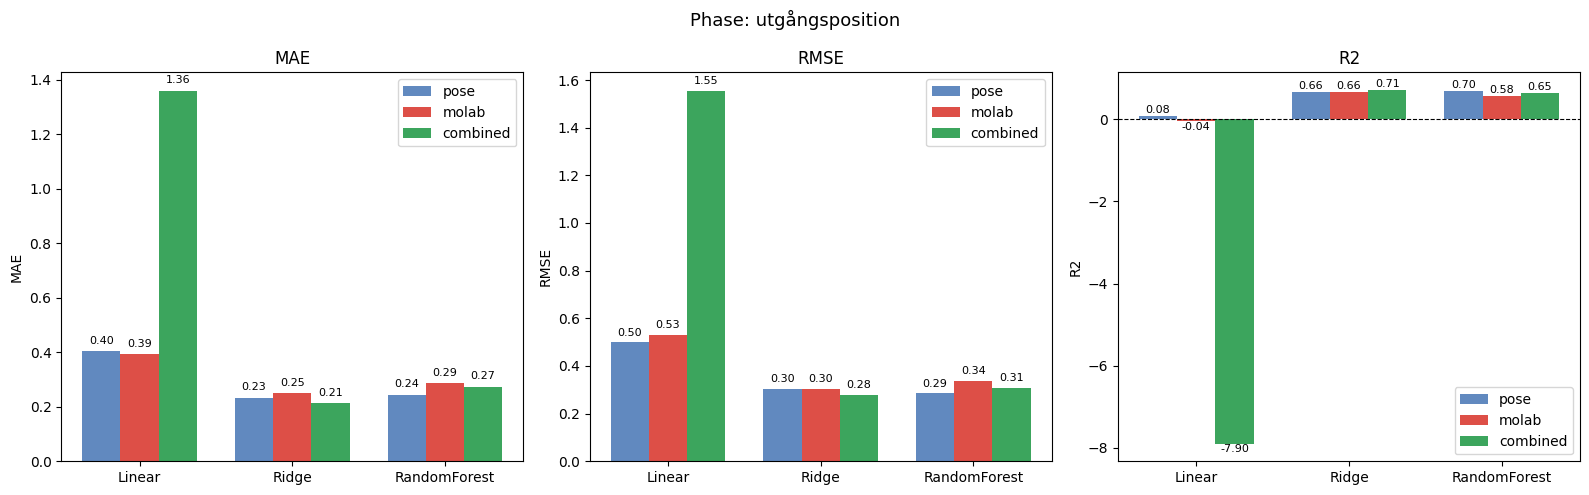

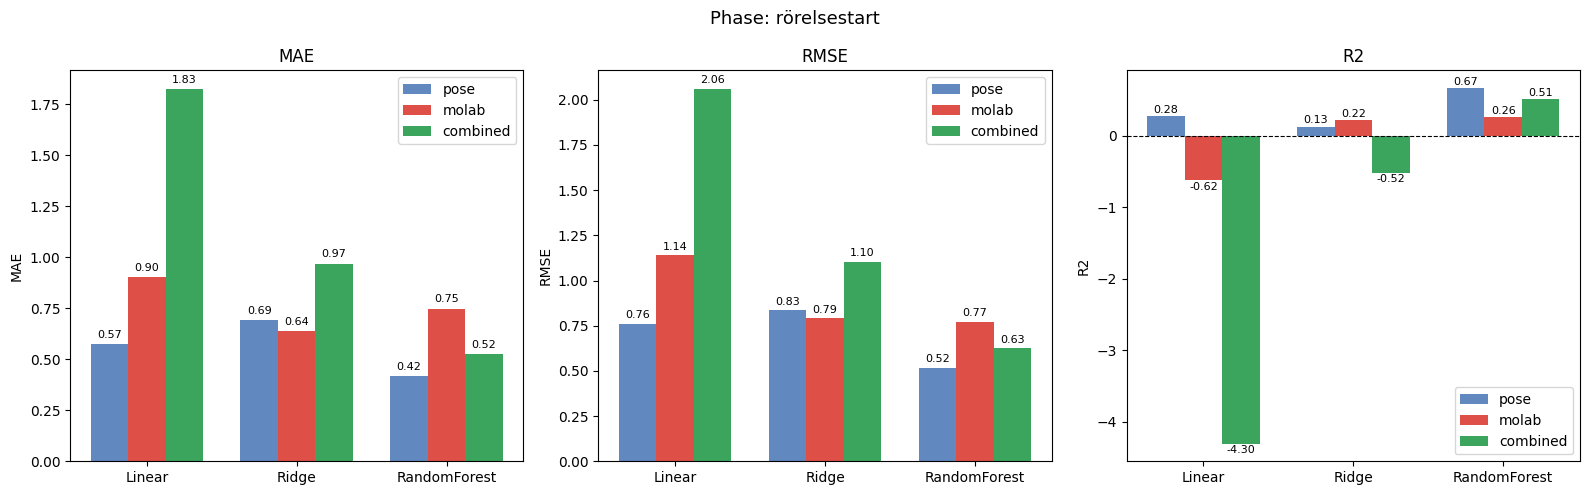

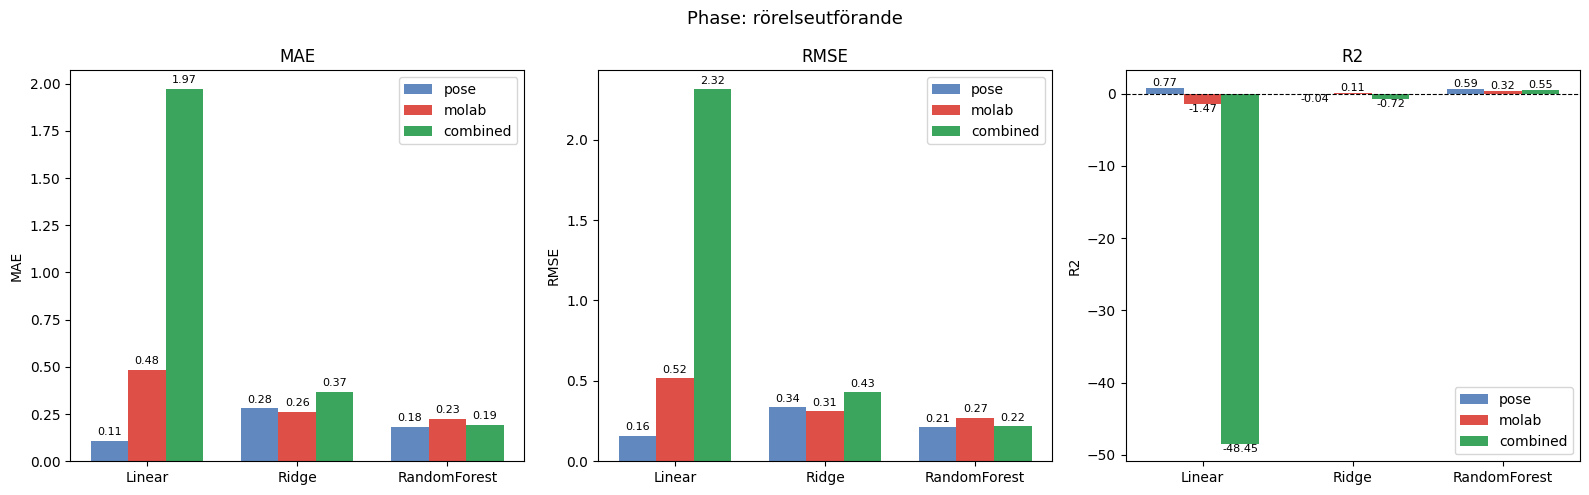

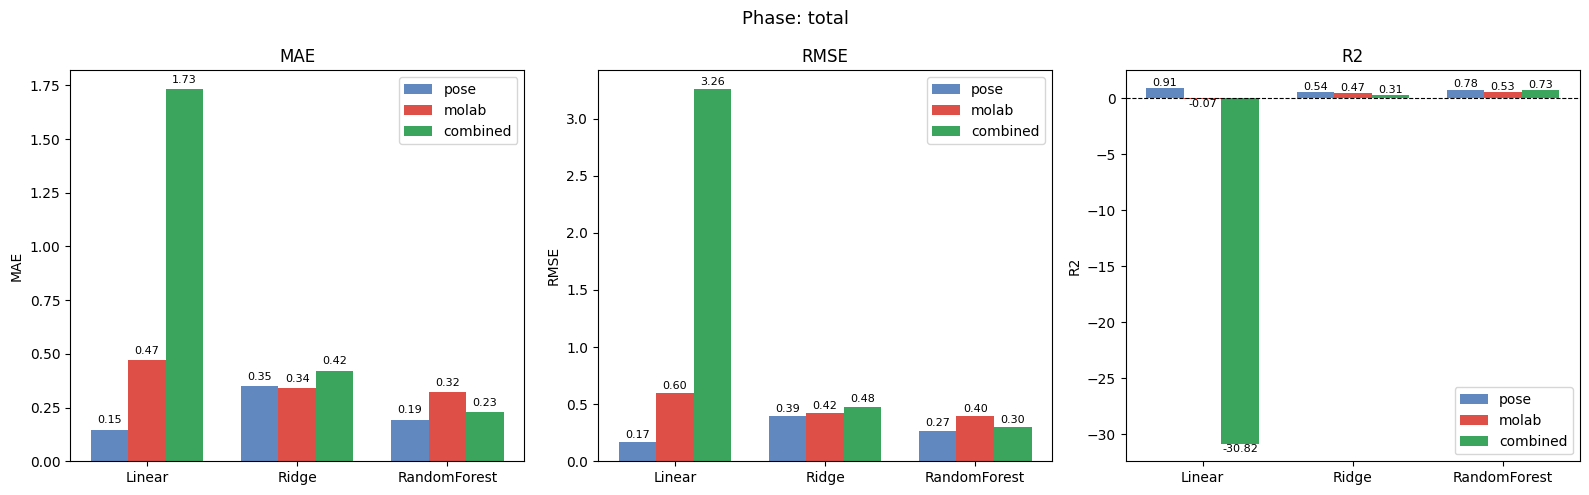

In [59]:
METRICS      = ['MAE', 'RMSE', 'R2']
COLORS       = {'pose': '#4575b4', 'molab': '#d73027', 'combined': '#1a9641'}

x = np.arange(len(MODEL_ORDER))
width = 0.25

for phase in eval_df['phase'].unique():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Phase: {phase}', fontsize=13)

    for ax, metric in zip(axes, METRICS):
        sub = eval_df[eval_df['phase'] == phase]
        for i, fs in enumerate(FEATURE_SETS):
            vals = [sub[(sub['model'] == m) & (sub['feature_set'] == fs)][metric].values[0]
                    for m in MODEL_ORDER]
            bars = ax.bar(x + i * width, vals, width, label=fs, color=COLORS[fs], alpha=0.85)
            for bar, val in zip(bars, vals):
                y_pos = bar.get_height() + (0.02 if val >= 0 else -0.02)
                va = 'bottom' if val >= 0 else 'top'
                ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                        f'{val:.2f}', ha='center', va=va, fontsize=8)

        ax.set_title(metric)
        ax.set_xticks(x + width)
        ax.set_xticklabels(MODEL_ORDER)
        ax.set_ylabel(metric)
        if metric == 'R2':
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_DIR / f'regression_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()

## ANOVA: prediction errors across feature sets

In [60]:
anova_rows = []

for phase in eval_df['phase'].unique():
    for model in MODEL_ORDER:
        errors = {}
        for fs in FEATURE_SETS:
            r = next(x for x in loocv_results
                     if x['phase'] == phase and x['model'] == model and x['feature_set'] == fs)
            errors[fs] = np.abs(r['y_true'] - r['y_pred'])

        f_stat, p_val = f_oneway(errors['pose'], errors['molab'], errors['combined'])
        anova_rows.append({
            'phase': phase, 'model': model,
            'F': round(f_stat, 3), 'p': round(p_val, 3),
            'significant': p_val < 0.05,
        })

anova_df = pd.DataFrame(anova_rows)
anova_df

,phase,model,F,p,significant
0,utgångsposition,Linear,10.665,0.000,True
1,utgångsposition,Ridge,0.088,0.916,False
2,utgångsposition,RandomForest,0.170,0.845,False
3,rörelsestart,Linear,6.908,0.004,True
4,rörelsestart,Ridge,1.200,0.317,False
5,rörelsestart,RandomForest,3.154,0.059,False
6,rörelseutförande,Linear,17.266,0.000,True
7,rörelseutförande,Ridge,0.753,0.480,False
8,rörelseutförande,RandomForest,0.314,0.733,False
9,total,Linear,2.438,0.106,False


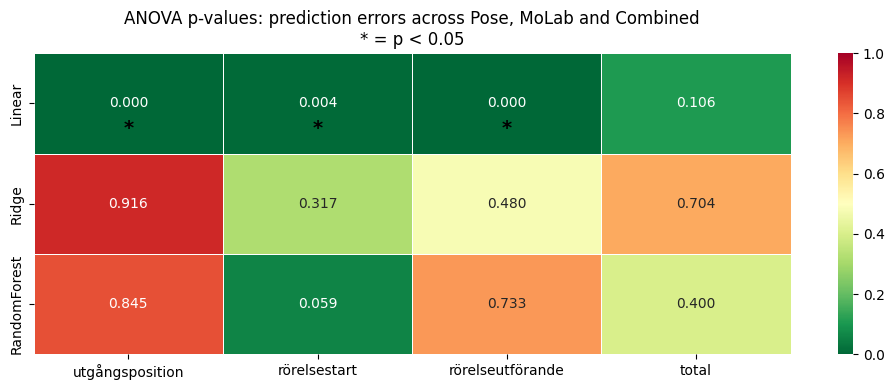

In [61]:
PHASE_ORDER = ['utgångsposition', 'rörelsestart', 'rörelseutförande', 'total']

pivot_p = anova_df.pivot(index='model', columns='phase', values='p')
pivot_p = pivot_p.loc[MODEL_ORDER, PHASE_ORDER]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_p, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 10})
for i, model in enumerate(pivot_p.index):
    for j, phase in enumerate(pivot_p.columns):
        if pivot_p.loc[model, phase] < 0.05:
            ax.text(j + 0.5, i + 0.75, '*', ha='center', va='center', fontsize=14, fontweight='bold')

ax.set_title('ANOVA p-values: prediction errors across Pose, MoLab and Combined\n* = p < 0.05', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUT_DIR / 'anova_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance (Random Forest)

In [62]:
for phase in PHASE_ORDER:
    print(f"\n{'='*60}")
    print(f"Phase: {phase}")
    print(f"{'='*60}")
    for fs in FEATURE_SETS:
        r = next(x for x in loocv_results
                 if x['phase'] == phase and x['model'] == 'RandomForest' and x['feature_set'] == fs)
        df = pd.DataFrame({
            'feature':    r['feature_names'],
            'importance': r['mean_importances'],
        }).sort_values('importance', ascending=False).reset_index(drop=True)
        print(f"\n{fs}:")
        print(df.round(4).to_string(index=False))


Phase: utgångsposition

pose:
                         feature  importance
pose_forb_rms_trunk_acceleration      0.3376
           pose_mean_trunk_angle      0.2517
        pose_initial_trunk_angle      0.2256
   pose_forb_delta_trunk_flexion      0.1008
        pose_delta_trunk_flexion      0.0844

molab:
                    feature  importance
   molab_mean_L_hip_flexion      0.3846
       molab_rms_pelvis_acc      0.1907
     molab_peak_pelvis_gyro      0.1893
molab_forb_peak_pelvis_gyro      0.1312
    molab_delta_pelvis_tilt      0.1042

combined:
                         feature  importance
        molab_mean_L_hip_flexion      0.2845
           pose_mean_trunk_angle      0.1107
            molab_rms_pelvis_acc      0.1036
pose_forb_rms_trunk_acceleration      0.0982
          molab_peak_pelvis_gyro      0.0960
        pose_initial_trunk_angle      0.0780
   pose_forb_delta_trunk_flexion      0.0675
     molab_forb_peak_pelvis_gyro      0.0642
        pose_delta_trunk_flexion   

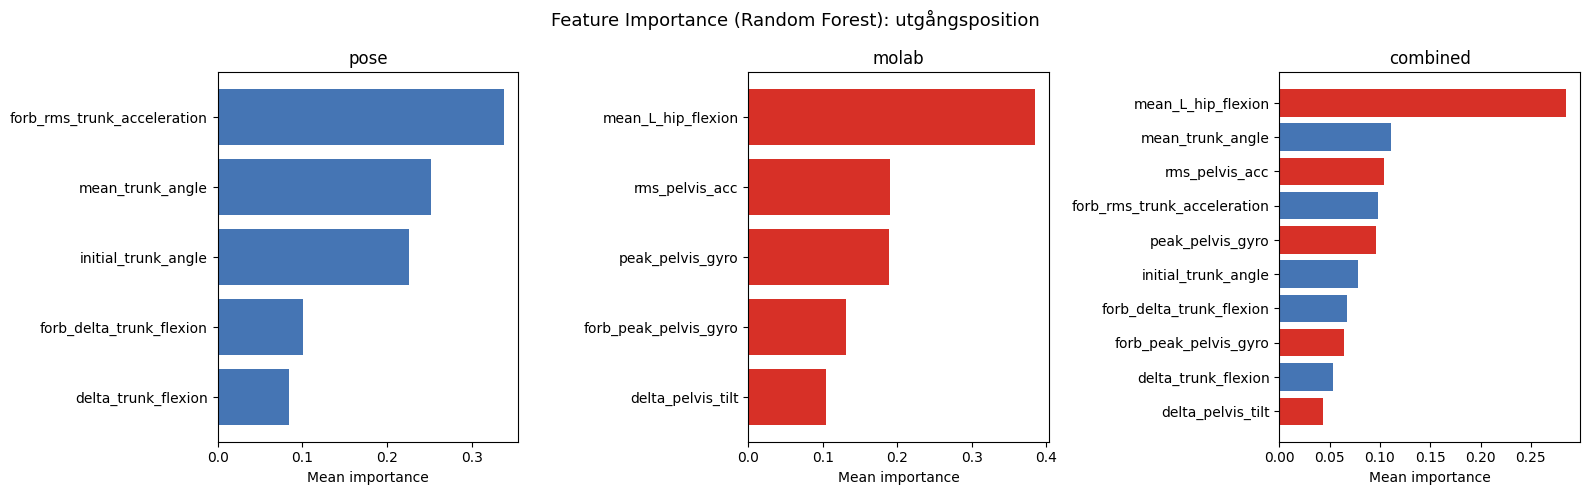

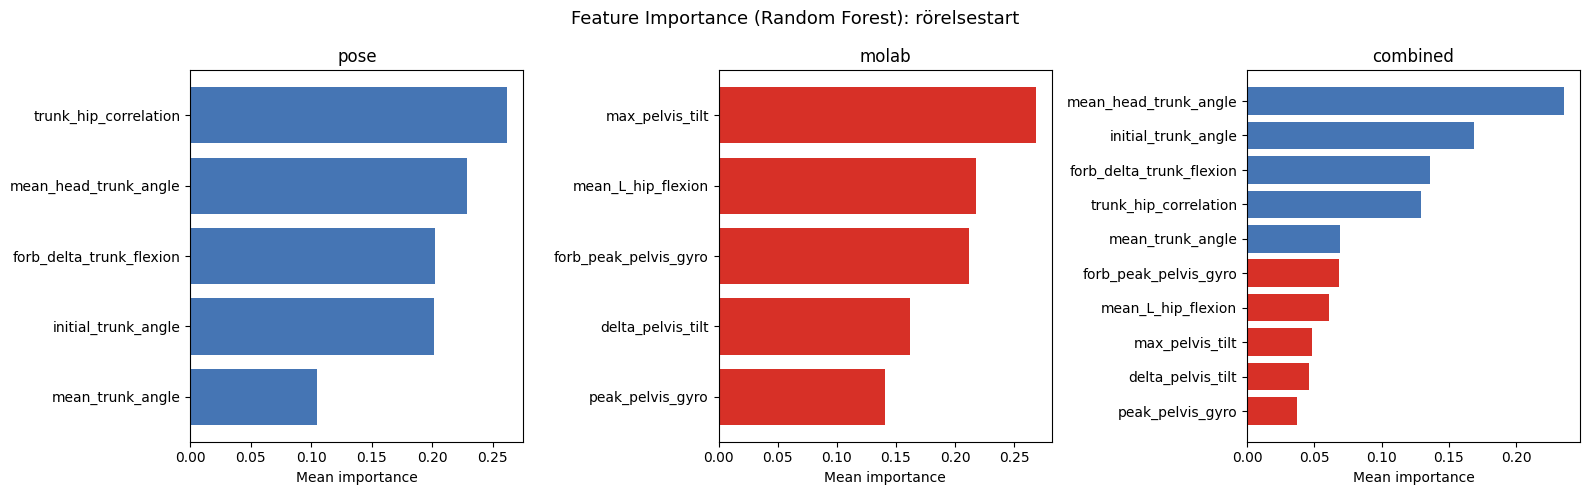

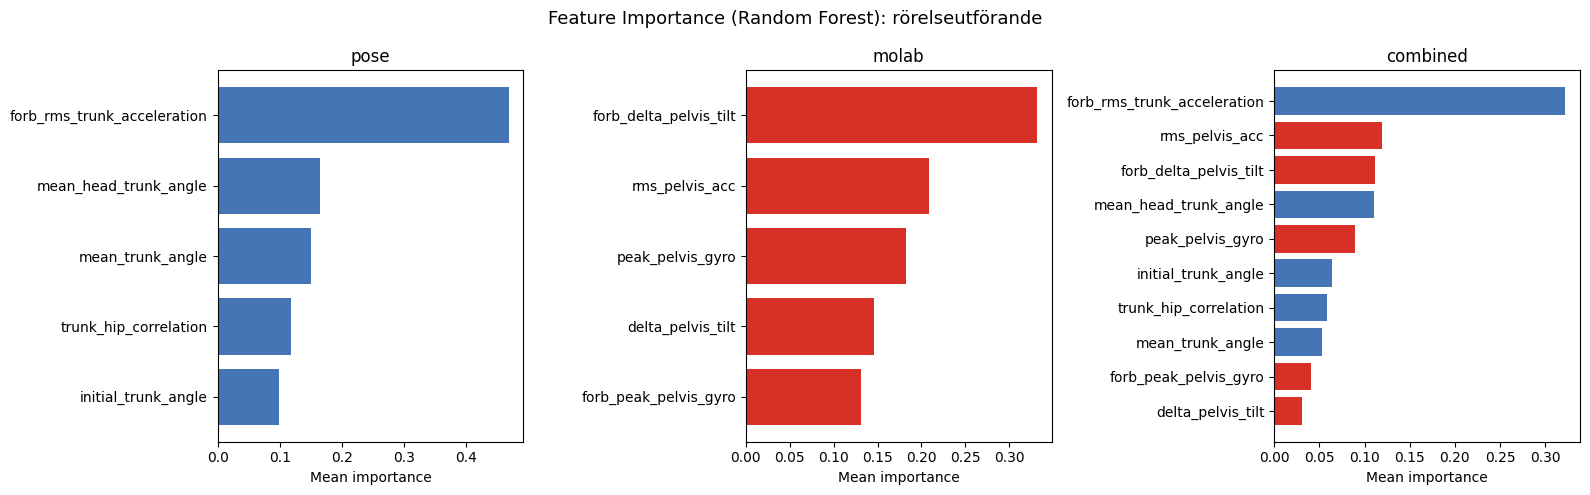

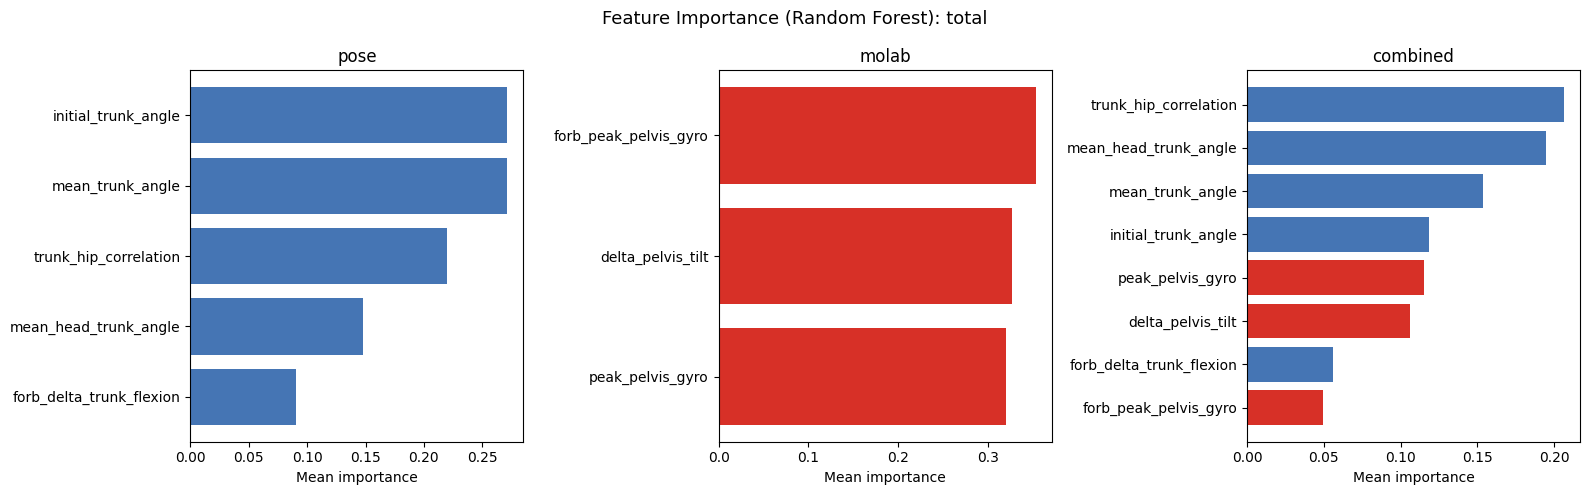

In [63]:
PHASE_ORDER = ['utgångsposition', 'rörelsestart', 'rörelseutförande', 'total']

for phase in PHASE_ORDER:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Feature Importance (Random Forest): {phase}', fontsize=13)

    for ax, fs in zip(axes, FEATURE_SETS):
        r = next(x for x in loocv_results
                 if x['phase'] == phase and x['model'] == 'RandomForest' and x['feature_set'] == fs)
        names = [n.replace('pose_', '').replace('molab_', '') for n in r['feature_names']]
        imps  = r['mean_importances']
        order = np.argsort(imps)
        colors = ['#d73027' if 'molab_' in r['feature_names'][i] else '#4575b4' for i in order]
        ax.barh([names[i] for i in order], imps[order], color=colors)
        ax.set_title(fs)
        ax.set_xlabel('Mean importance')

    plt.tight_layout()
    plt.savefig(OUT_DIR / f'feature_importance_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Error Analysis (Random Forest): Pose vs MoLab per video

In [64]:
for phase in PHASE_ORDER:
    pose_r  = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'pose')
    molab_r = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'molab')

    df = pd.DataFrame({
        'video':       videos,
        'pose_error':  np.abs(pose_r['y_true']  - pose_r['y_pred']),
        'molab_error': np.abs(molab_r['y_true'] - molab_r['y_pred']),
    })
    df['better'] = df.apply(lambda row: 'Pose' if row['pose_error'] < row['molab_error'] else 'MoLab', axis=1)

    print(f"\n{'='*60}")
    print(f"Phase: {phase}")
    print(f"{'='*60}")
    print(df.round(4).to_string(index=False))


Phase: utgångsposition
video  pose_error  molab_error better
  028      0.0724       0.1992   Pose
  030      0.3663       0.6854   Pose
  045      0.3179       0.0606  MoLab
  047      0.4132       0.2268  MoLab
  059      0.3043       0.2471  MoLab
  061      0.0145       0.1174   Pose
  074      0.0010       0.4433   Pose
  076      0.2765       0.3006   Pose
  091      0.3381       0.4416   Pose
  093      0.3428       0.1445  MoLab

Phase: rörelsestart
video  pose_error  molab_error better
  028        0.40       0.2533  MoLab
  030        1.04       0.7300  MoLab
  045        0.24       0.8733   Pose
  047        0.10       0.7467   Pose
  059        0.14       0.6767   Pose
  061        0.34       0.7000   Pose
  074        0.20       0.8400   Pose
  076        0.18       0.8067   Pose
  091        0.78       0.9800   Pose
  093        0.74       0.8800   Pose

Phase: rörelseutförande
video  pose_error  molab_error better
  028      0.1587       0.2050   Pose
  030      0.3738 

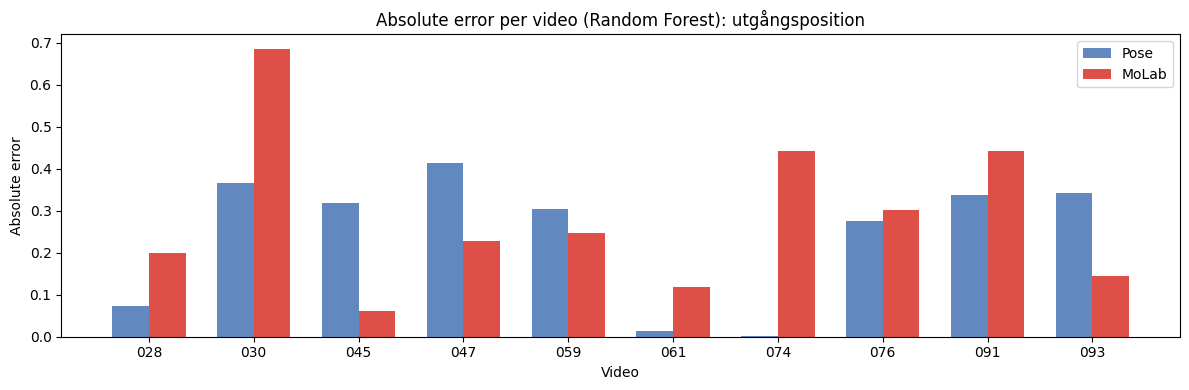

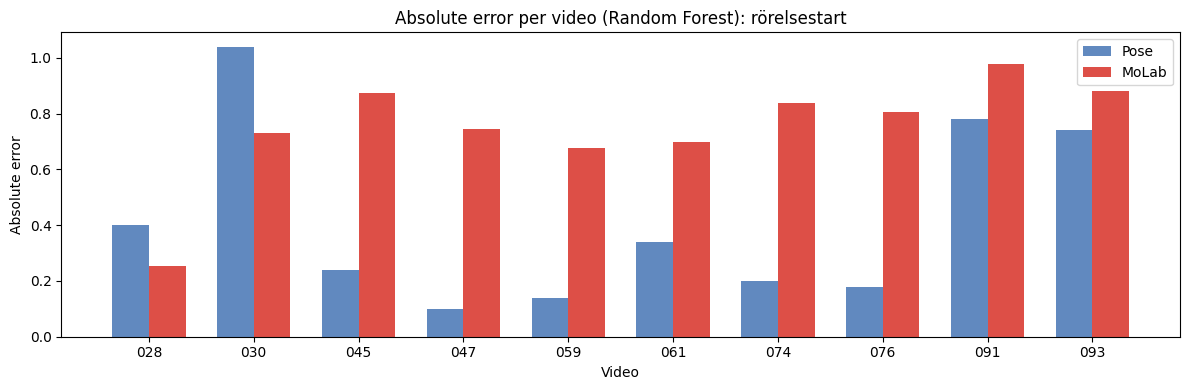

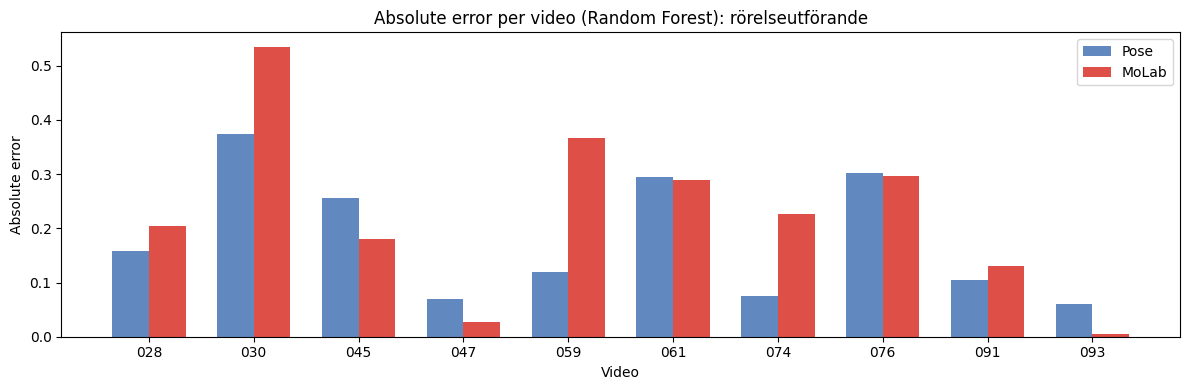

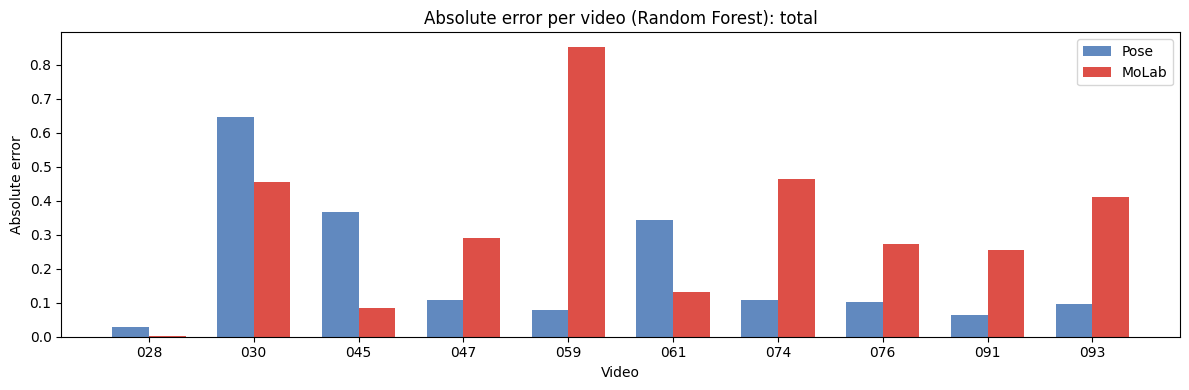

In [65]:
videos = phase_dfs['utgångsposition']['y']['video'].tolist()

x = np.arange(len(videos))
width = 0.35

for phase in PHASE_ORDER:
    pose_r  = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'pose')
    molab_r = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'molab')

    pose_errors  = np.abs(pose_r['y_true']  - pose_r['y_pred'])
    molab_errors = np.abs(molab_r['y_true'] - molab_r['y_pred'])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x - width/2, pose_errors,  width, label='Pose',  color='#4575b4', alpha=0.85)
    ax.bar(x + width/2, molab_errors, width, label='MoLab', color='#d73027', alpha=0.85)

    ax.set_title(f'Absolute error per video (Random Forest): {phase}')
    ax.set_xticks(x)
    ax.set_xticklabels(videos)
    ax.set_xlabel('Video')
    ax.set_ylabel('Absolute error')
    ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_DIR / f'error_analysis_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()